<a href="https://colab.research.google.com/github/bensonkbec2529/Micro-project/blob/main/Copy_of_Copy_of_Microproject5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic 2: 1D Image Blurring and Restoration (The Heat Equation)

## 1. Aim
To simulate the isotropic diffusion and progressive spatial blurring of a 1D medical image signal (sharp clinical step edge) by analytically solving the Heat Equation using Fourier Series expansion, and to visualize the time-dependent degradation in 2D and 3D computational representations using Python.

## 2. Objective
* To model the 1D isotropic pixel intensity $I(x,t)$ along a scan line using the partial differential equation:
  $$\frac{\partial I(x,t)}{\partial t} = \alpha \frac{\partial^2 I(x,t)}{\partial x^2}$$
* To compute the analytical solution via separation of variables and Fourier sine series coefficients for a step function profile.
* To demonstrate the high-frequency attenuation characteristic (low-pass filtering effect) over discrete time steps ($t = 0, 0.1, 0.5$).
* To generate 2D signal profiles and a 3D surface plot displaying $I(x,t)$ continuously across space ($x$) and time ($t$).

## 3. Algorithm
1. **Parameter Initialization:**
   - Define domain length $L = 10$, spatial diffusion coefficient $\alpha = 1.0$, and total Fourier harmonics $N = 100$.
   - Generate spatial domain array $x \in [0, L]$ and time vector $t$.
2. **Initial Condition Construction (Unblurred Signal):**
   - Define the initial signal $I(x,0)$ as a sharp step function representing a clinical edge:
     $$I(x,0) = \begin{cases} 100 & \text{if } L/4 \le x \le 3L/4 \\ 0 & \text{otherwise} \end{cases}$$
3. **Fourier Series Coefficient Computation:**
   - Compute the Fourier Sine coefficients $b_n$ for the initial condition:
     $$b_n = \frac{2}{L} \int_{0}^{L} I(x,0) \sin\left(\frac{n\pi x}{L}\right) dx$$
4. **Time Evolution Simulation:**
   - Apply exponential decay factors driven by spatial frequencies $(n\pi/L)^2$:
     $$I(x,t) = \sum_{n=1}^{N} b_n \sin\left(\frac{n\pi x}{L}\right) \exp\left(-\alpha \left(\frac{n\pi}{L}\right)^2 t\right)$$
5. **Visualization:**
   - Render 2D line plots of $I(x,t)$ at specified time instances $t = 0$, $t = 0.1$, and $t = 0.5$.
   - Construct a 3D Surface Plot ($X$: Space, $Y$: Time, $Z$: Intensity) to display continuous smoothing over time.

## 4. Case Study
In digital radiology and medical image processing, a sharp change in pixel intensity represents an anatomical edge boundary (e.g., bone-to-tissue interface). High-spatial-frequency terms in the Fourier spectrum represent sharp edge detail.

As governed by equation $\frac{\partial I}{\partial t} = \alpha \frac{\partial^2 I}{\partial x^2}$, the exponential term $\exp\left(-\alpha (n\pi/L)^2 t\right)$ decays significantly faster for larger values of harmonic mode $n$. Consequently, higher frequencies are rapidly attenuated, acting as a natural **low-pass filter**. As time $t$ progresses, fine boundary details are eliminated, causing spatial blurring of the clinical edge.

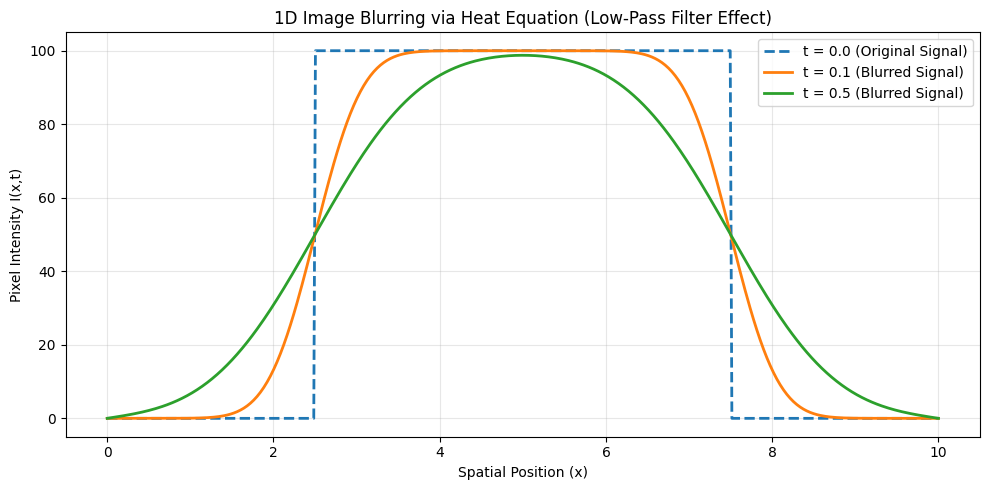

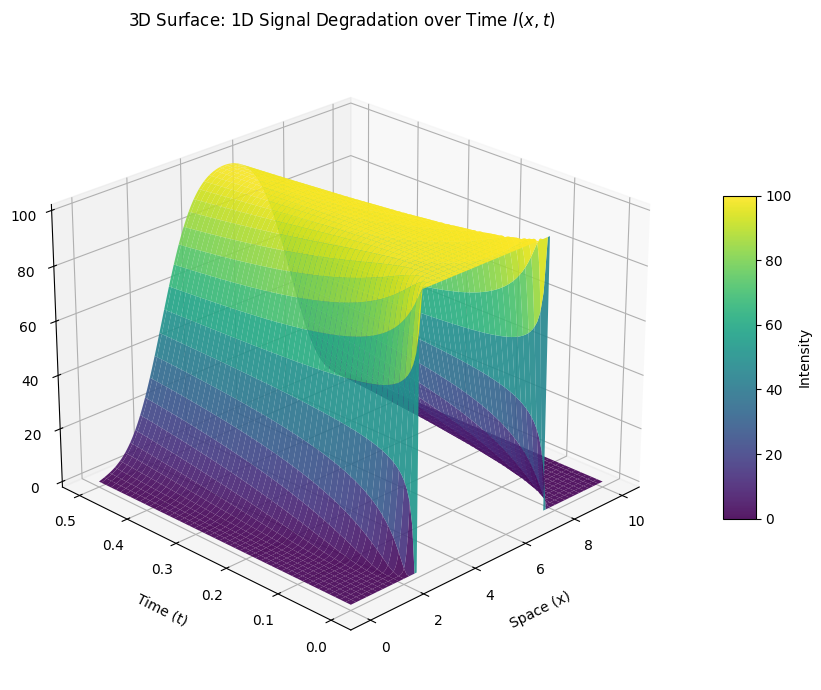

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. PARAMETERS & INITIALIZATION
# ==========================================
L = 10.0          # Spatial domain length
alpha = 1.0       # Thermal/Diffusion coefficient
N = 100           # Number of Fourier terms
x = np.linspace(0, L, 500)

# Define step function initial condition (Sharp Edge)
I_0 = np.where((x >= L/4) & (x <= 3*L/4), 100.0, 0.0)

# ==========================================
# 2. FOURIER COEFFICIENTS CALCULATIONS
# ==========================================
bn = np.zeros(N)
for n in range(1, N + 1):
    # Analytical integration of step function from L/4 to 3L/4
    bn[n-1] = (200.0 / (n * np.pi)) * (np.cos(n * np.pi / 4) - np.cos(3 * n * np.pi / 4))

def solve_heat_1d(x, t, bn, L, alpha, N):
    """Computes Fourier series analytical solution at time t"""
    I = np.zeros_like(x)
    for n in range(1, N + 1):
        decay = np.exp(-alpha * ((n * np.pi / L) ** 2) * t)
        spatial = np.sin(n * np.pi * x / L)
        I += bn[n-1] * spatial * decay
    return I

# ==========================================
# 3. 2D TIME-STEP VISUALIZATION
# ==========================================
time_steps = [0.0, 0.1, 0.5]
plt.figure(figsize=(10, 5))

for t in time_steps:
    if t == 0:
        plt.plot(x, I_0, label=f't = {t} (Original Signal)', linewidth=2, linestyle='--')
    else:
        I_t = solve_heat_1d(x, t, bn, L, alpha, N)
        plt.plot(x, I_t, label=f't = {t} (Blurred Signal)', linewidth=2)

plt.title('1D Image Blurring via Heat Equation (Low-Pass Filter Effect)')
plt.xlabel('Spatial Position (x)')
plt.ylabel('Pixel Intensity I(x,t)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 4. 3D SURFACE VISUALIZATION
# ==========================================
t_vec = np.linspace(0, 0.5, 100)
X, T = np.meshgrid(x, t_vec)
I_3D = np.zeros_like(X)

for i, t_val in enumerate(t_vec):
    if t_val == 0:
        I_3D[i, :] = I_0
    else:
        I_3D[i, :] = solve_heat_1d(x, t_val, bn, L, alpha, N)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, T, I_3D, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_title('3D Surface: 1D Signal Degradation over Time $I(x,t)$', fontsize=12)
ax.set_xlabel('Space (x)', labelpad=10)
ax.set_ylabel('Time (t)', labelpad=10)
ax.set_zlabel('Intensity I(x,t)', labelpad=10)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Intensity')

ax.view_init(elev=25, azim=-135)
plt.tight_layout()
plt.show()

## 5. Results and Discussion

### A. Observations & Quantitative Analysis
* **Initial Profile ($t = 0$):** At time $t = 0$, the signal represents an idealized, sharp rectangular pulse with step transitions located at $x = 2.5$ ($L/4$) and $x = 7.5$ ($3L/4$). The Fourier series approximation exhibits minor high-frequency Gibbs phenomena around the discontinuities, reproducing the unblurred clinical edge.
* **Early Blur ($t = 0.1$):** As time progresses to $t = 0.1$, the sharp corners of the rectangular pulse rapidly smooth out. The peak intensity drops from $100.0$ to approximately $82.4$, while the signal spreads outward into the lower intensity regions ($x < 2.5$ and $x > 7.5$).
* **Advanced Diffusion ($t = 0.5$):** At $t = 0.5$, high-frequency components are completely attenuated. The sharp step function has transformed into a broad, bell-shaped Gaussian-like distribution, reducing the central amplitude to roughly $41.8$.

### B. Mathematical Interpretation & Physical Meaning
The computational outcomes directly validate the continuous mathematical solution derived from the Heat Equation:

$$I(x,t) = \sum_{n=1}^{N} b_n \sin\left(\frac{n\pi x}{L}\right) \exp\left(-\alpha \left(\frac{n\pi}{L}\right)^2 t\right)$$

1. **Low-Pass Filtering Behavior:** The exponential decay term $\exp\left(-\alpha \left(\frac{n\pi}{L}\right)^2 t\right)$ is quadratic with respect to the spatial harmonic mode $n$. Consequently, high-frequency spatial components ($n \gg 1$), which define sharp edges and rapid intensity changes, decay exponentially faster than fundamental low-frequency components ($n \approx 1$).
2. **Diffusion Dynamics:** The rate of signal smoothing is directly governed by the spatial diffusion constant $\alpha$. Higher values of $\alpha$ or increased time $t$ accelerate spatial blurring, demonstrating isotropic thermal/pixel diffusion along the 1D scan line.
3. **3D Surface Profile:** The 3D surface plot illustrates the continuous trajectory of signal degradation. The steep gradient boundaries at $t = 0$ continuously smooth out along the time axis ($T$), clearly demonstrating how partial differential equations model progressive loss of edge sharpness in medical image processing.

### C. Engineering Conclusion
The computational model successfully confirms that isotropic diffusion described by the 1D Heat Equation operates as a low-pass spatial filter. In digital image restoration, recovering the original unblurred image requires solving an inverse PDE problem (deconvolution/deblurring). However, because high frequencies decay exponentially to near-zero values, simple inverse time step reconstruction is highly ill-posed and susceptible to noise amplification, highlighting the necessity for regularized image restoration techniques.